In [21]:
import matplotlib.pyplot as plt

In [ ]:
pip install yfinance

In [4]:
import yfinance as yf

In [2]:
tickers = [
    "AAPL",
    "MSFT",
    "AMZN",
    "GOOGL",
    "META",
    "NVDA",
    "TSLA",
    "JPM",
    "V",
    "KO"
]

In [6]:
prices = yf.download(
    tickers,
    start="2020-01-01",
    end="2025-01-01"
)["Close"]

[*********************100%***********************]  10 of 10 completed


In [7]:
prices.head()

Ticker,AAPL,AMZN,GOOGL,JPM,KO,META,MSFT,NVDA,TSLA,V
Date,,,,,,,,,,
2020-01-02,72.333862,94.900497,67.832504,117.899208,45.141262,207.953842,151.829544,5.963803,28.684000,182.431076
2020-01-03,71.630646,93.748497,67.477661,116.343346,44.894997,206.853485,149.939011,5.868347,29.534000,180.980194
2020-01-06,72.201416,95.143997,69.276207,116.250854,44.878578,210.749298,150.326584,5.892956,30.102667,180.588821
2020-01-07,71.861839,95.343002,69.142395,114.274521,44.533798,211.205276,148.955933,5.964301,31.270666,180.111557
2020-01-08,73.017830,94.598503,69.634529,115.165955,44.615883,213.346497,151.328583,5.975487,32.809334,183.194702


In [8]:
momentum = prices.pct_change(252)

In [9]:
latest_rank = momentum.iloc[-1].sort_values(ascending=False)

latest_rank

Ticker
NVDA     1.712493
META     0.660489
TSLA     0.625241
AMZN     0.443925
JPM      0.442882
GOOGL    0.360056
AAPL     0.307052
V        0.223183
MSFT     0.129273
KO       0.088775
Name: 2024-12-31 00:00:00, dtype: float64

In [10]:
monthly_prices = prices.resample("ME").last()

In [11]:
monthly_prices.head()

Ticker,AAPL,AMZN,GOOGL,JPM,KO,META,MSFT,NVDA,TSLA,V
Date,,,,,,,,,,
2020-01-31,74.539886,100.435997,71.009354,111.314186,47.940529,200.152359,160.913620,5.877296,43.371334,189.924164
2020-02-29,65.990051,94.187500,66.373947,97.648003,43.909920,190.794510,153.561813,6.717551,44.532665,173.747894
2020-03-31,61.386501,97.486000,57.586864,75.714828,36.643375,165.347992,149.486023,6.556622,34.933334,154.017731
2020-04-30,70.924362,123.699997,66.743179,81.370628,38.001453,202.927994,169.864868,7.269989,52.125332,170.841858
2020-05-31,76.959564,122.118500,71.046021,82.687706,38.655651,223.130554,174.177933,8.830543,55.666668,186.946136


In [12]:
monthly_momentum = monthly_prices.pct_change(12)

In [13]:
top3 = monthly_momentum.rank(axis=1, ascending=False).apply(
    lambda x: x <= 3
)

top3.tail()

Ticker,AAPL,AMZN,GOOGL,JPM,KO,META,MSFT,NVDA,TSLA,V
Date,,,,,,,,,,
2024-08-31,False,False,False,True,False,True,False,True,False,False
2024-09-30,False,False,False,True,False,True,False,True,False,False
2024-10-31,False,False,False,True,False,True,False,True,False,False
2024-11-30,False,False,False,True,False,True,False,True,False,False
2024-12-31,False,False,False,False,False,True,False,True,True,False


In [14]:
monthly_returns = monthly_prices.pct_change()

monthly_returns.head()

Ticker,AAPL,AMZN,GOOGL,JPM,KO,META,MSFT,NVDA,TSLA,V
Date,,,,,,,,,,
2020-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-29,-0.114701,-0.062214,-0.065279,-0.122771,-0.084075,-0.046754,-0.045688,0.142966,0.026776,-0.085172
2020-03-31,-0.069761,0.035021,-0.132388,-0.224615,-0.165488,-0.133371,-0.026542,-0.023957,-0.215557,-0.113556
2020-04-30,0.155374,0.268900,0.159000,0.074699,0.037062,0.227278,0.136326,0.108801,0.492137,0.109235
2020-05-31,0.085093,-0.012785,0.064469,0.016186,0.017215,0.099555,0.025391,0.214657,0.067939,0.094264


In [16]:
positions = top3.shift(1)

In [17]:
portfolio_returns = monthly_returns.where(positions)

In [18]:
portfolio_returns = portfolio_returns.mean(axis=1)

In [19]:
portfolio_growth = (1 + portfolio_returns.fillna(0)).cumprod()

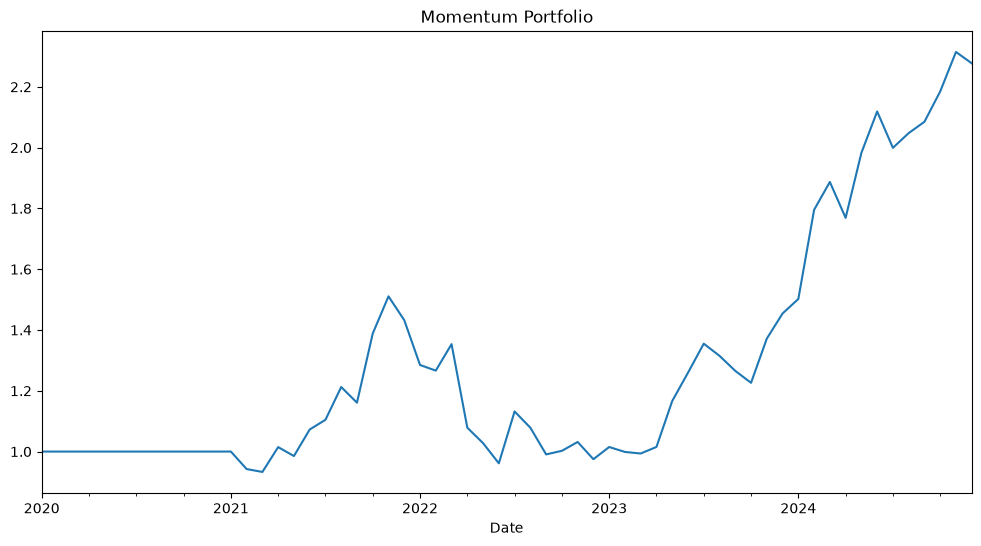

In [22]:
portfolio_growth.plot(figsize=(12,6))

plt.title("Momentum Portfolio")
plt.show()